=== Spatial Lag Model (SLM) ===
R2: 0.900   RMSE Residuals: 0.932   Moran's I (Residuals): 0.007
RMSE Spatial Lag: 0.034   RMSE Param1 (β1·X1): 0.035   RMSE Param2 (β2·X2): 0.024

=== XGBoost + SHAP ===
R2: 1.000   RMSE Residuals: 0.027   Moran's I (Residuals): -0.012
RMSE Spatial Lag: 0.633   RMSE Param1 (X1): 0.466   RMSE Param2 (X2): 0.525


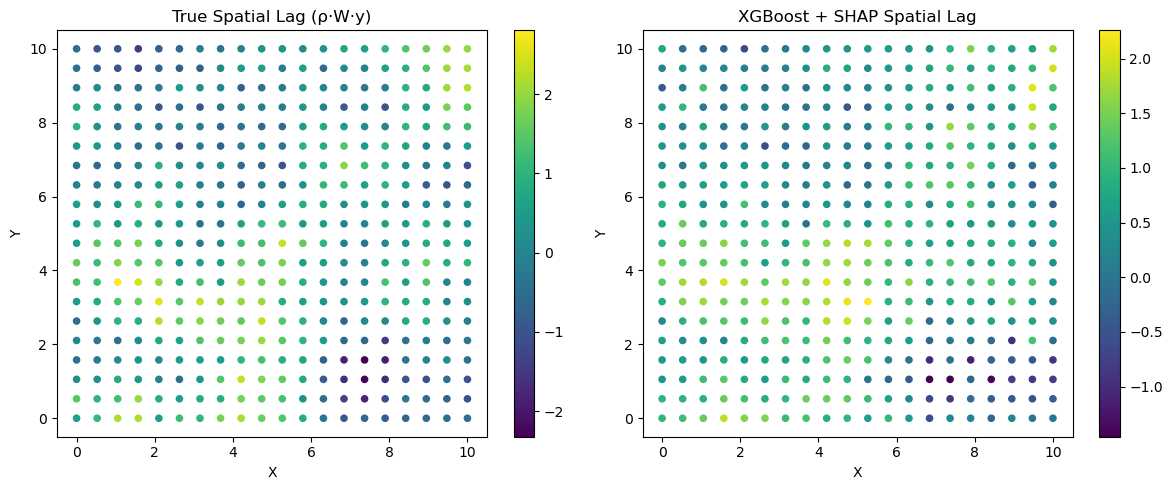

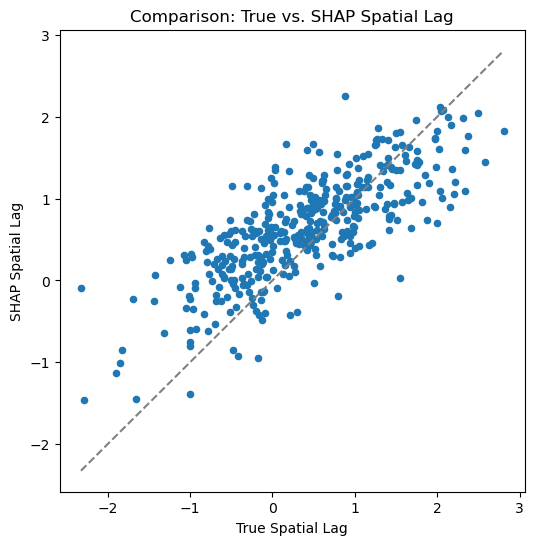

In [1]:
import numpy as np
import pandas as pd
from libpysal.weights import KNN
from esda.moran import Moran
from spreg import ML_Lag
import xgboost as xgb
import matplotlib.pyplot as plt

# ------------------------------
# 1. Generate synthetic spatial data on a grid
# ------------------------------
n_side = 20
xs = np.linspace(0, 10, n_side)
ys = np.linspace(0, 10, n_side)
xx, yy = np.meshgrid(xs, ys)
coords = np.column_stack([xx.ravel(), yy.ravel()])
N = coords.shape[0]

# ------------------------------
# 2. Create features (X1, X2)
# ------------------------------
np.random.seed(0)
X1 = np.random.normal(size=N)
X2 = np.random.normal(size=N)
X = np.column_stack([X1, X2])

# ------------------------------
# 3. Build spatial weights (8-NN, row-standardized)
# ------------------------------
knn = KNN.from_array(coords, k=8)
knn.transform = 'R'  # row-standardize weights
W_mat = knn.full()[0]  # dense weight matrix

# ------------------------------
# 4. Simulate y using a spatial lag model:
#      y = (I - ρ W)^(-1)(Xβ + noise)
# ------------------------------
rho_true = 0.6
beta_true = np.array([1.5, -2.0])
noise = np.random.normal(scale=1.0, size=N)
A = np.eye(N) - rho_true * W_mat
y = np.linalg.solve(A, X.dot(beta_true) + noise)

# Compute the true spatial lag term: ρ·W·y
spatial_lag_true = rho_true * W_mat.dot(y)

# ------------------------------
# 5. Fit a Spatial Lag Model (SLM) using ML_Lag from spreg
# ------------------------------
# ML_Lag expects y as a 2D array and a PySAL weights object.
model_slm = ML_Lag(y.reshape(-1, 1), X, w=knn, name_y='y', name_x=['X1', 'X2'])
rho_est = model_slm.rho  # ρ is a scalar, so no indexing
betas = model_slm.betas.flatten()   # Order: [constant, β1, β2]
yhat_slm = model_slm.predy.flatten()
resid_slm = y - yhat_slm

# ------------------------------
# 6. Fit an XGBoost Model (with spatial coordinates as extra features)
# ------------------------------
df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'x': coords[:, 0],
    'y': coords[:, 1]
})
X_feat = df[['X1', 'X2', 'x', 'y']]
# Use a DMatrix for XGBoost (set parameters to avoid GPU if needed)
params = {'objective': 'reg:squarederror', 'verbosity': 0, 'tree_method': 'hist', 'nthread': 1}
dtrain = xgb.DMatrix(X_feat, label=y)
xgb_model = xgb.train(params, dtrain, num_boost_round=100)

# ------------------------------
# 7. Extract Tree-SHAP contributions from XGBoost
# ------------------------------
# The XGBoost predict method with pred_contribs=True returns an array of shape (N, num_features + 1)
# where columns 0..3 correspond to the contributions for features [X1, X2, x, y] and the final column is the bias.
shap_contribs = xgb_model.predict(dtrain, pred_contribs=True)
# To follow Li (2022), compute the SHAP spatial lag as:
#   SHAP spatial lag = SHAP(x) + SHAP(y) + bias
shap_spatial_lag = shap_contribs[:, 2] + shap_contribs[:, 3] + shap_contribs[:, -1]
# Also extract parameter contributions for the features X1 and X2
shap_p1 = shap_contribs[:, 0]
shap_p2 = shap_contribs[:, 1]

# XGBoost predictions and residuals:
yhat_xgb = xgb_model.predict(dtrain)
resid_xgb = y - yhat_xgb

# ------------------------------
# 8. Compute performance metrics
# ------------------------------
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def r2(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)

# SLM Metrics
R2_slm         = r2(y, yhat_slm)
RMSE_resid_slm = rmse(y, yhat_slm)
MI_resid_slm   = Moran(resid_slm, knn).I
# Compare the true spatial lag with the estimated one from SLM (using estimated ρ)
RMSE_lag_slm   = rmse(spatial_lag_true, rho_est * W_mat.dot(y))
RMSE_p1_slm    = rmse(beta_true[0] * X1, betas[1] * X1)
RMSE_p2_slm    = rmse(beta_true[1] * X2, betas[2] * X2)

# XGBoost + SHAP Metrics
R2_xgb         = r2(y, yhat_xgb)
RMSE_resid_xgb = rmse(y, yhat_xgb)
MI_resid_xgb   = Moran(resid_xgb, knn).I
RMSE_lag_xgb   = rmse(spatial_lag_true, shap_spatial_lag)
RMSE_p1_xgb    = rmse(beta_true[0] * X1, shap_p1)
RMSE_p2_xgb    = rmse(beta_true[1] * X2, shap_p2)

print("=== Spatial Lag Model (SLM) ===")
print(f"R2: {R2_slm:.3f}   RMSE Residuals: {RMSE_resid_slm:.3f}   Moran's I (Residuals): {MI_resid_slm:.3f}")
print(f"RMSE Spatial Lag: {RMSE_lag_slm:.3f}   RMSE Param1 (β1·X1): {RMSE_p1_slm:.3f}   RMSE Param2 (β2·X2): {RMSE_p2_slm:.3f}\n")

print("=== XGBoost + SHAP ===")
print(f"R2: {R2_xgb:.3f}   RMSE Residuals: {RMSE_resid_xgb:.3f}   Moran's I (Residuals): {MI_resid_xgb:.3f}")
print(f"RMSE Spatial Lag: {RMSE_lag_xgb:.3f}   RMSE Param1 (X1): {RMSE_p1_xgb:.3f}   RMSE Param2 (X2): {RMSE_p2_xgb:.3f}")

# ------------------------------
# 9. Visualize the spatial lag effects
# ------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sc1 = axs[0].scatter(coords[:, 0], coords[:, 1], c=spatial_lag_true, s=20, cmap='viridis')
axs[0].set_title("True Spatial Lag (ρ·W·y)")
axs[0].set_xlabel("X"); axs[0].set_ylabel("Y")
plt.colorbar(sc1, ax=axs[0])
sc2 = axs[1].scatter(coords[:, 0], coords[:, 1], c=shap_spatial_lag, s=20, cmap='viridis')
axs[1].set_title("XGBoost + SHAP Spatial Lag")
axs[1].set_xlabel("X"); axs[1].set_ylabel("Y")
plt.colorbar(sc2, ax=axs[1])
plt.tight_layout()
plt.show()

# ------------------------------
# 10. Scatter plot comparing True vs. SHAP spatial lag
# ------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(spatial_lag_true, shap_spatial_lag, s=20)
mn, mx = spatial_lag_true.min(), spatial_lag_true.max()
plt.plot([mn, mx], [mn, mx], linestyle='--', color='gray')
plt.xlabel("True Spatial Lag")
plt.ylabel("SHAP Spatial Lag")
plt.title("Comparison: True vs. SHAP Spatial Lag")
plt.show()
